# Homework 2: Feedforward Digit Classifier

**Course**: AI for Augmented and Virtual Reality (CSC 5991)
**Author**: Fahad Qaseem Khawar - hr4625
**Dataset**: MNIST (handwritten digits, 0–9)  
**Framework**: PyTorch 2.7

---

## What are we building?

We're going to train a **feedforward neural network** that looks at an image of a handwritten digit and predicts which number (0–9) it is.

A **feedforward** network means information flows in one direction only: **input → hidden layers → output**. There are no loops or cycles. It's the simplest kind of neural network — and it's surprisingly powerful.

### The Dataset: MNIST

MNIST is a classic benchmark dataset. It contains:
- **60,000 training images** (used to teach the network)
- **10,000 test images** (used to measure how well it learned)

Each image is a **28×28 grayscale picture** of a handwritten digit. That's 784 pixels per image.

### The Goal

Given a 28×28 image, predict which digit (0–9) it shows. This is a **classification problem** with 10 classes.

---
## Section 1: Imports & Setup

Before we do anything, we need to import the libraries (pre-written code packages) we'll use:

| Library | What it does |
|---|---|
| `torch` | The core PyTorch library — tensors, math, autograd |
| `torch.nn` | Building blocks for neural networks (layers, activations, loss functions) |
| `torchvision` | Computer vision tools — includes MNIST downloader |
| `matplotlib` | Plotting library — for drawing charts and images |
| `seaborn` | Built on matplotlib, makes prettier statistical plots |
| `numpy` | Numerical computing — arrays and math |

We also set a **random seed**. Neural networks initialize their weights randomly — by fixing the seed, we guarantee that if you run this notebook again, you'll get the exact same results.

In [1]:
# ── Standard library ───────────────────────────────────────────────
import os
import time

# ── Numerical computing ────────────────────────────────────────────
import numpy as np

# ── PyTorch core ───────────────────────────────────────────────────
import torch
import torch.nn as nn                     # Neural network layers
import torch.optim as optim               # Optimizers (Adam, SGD, …)
from torch.utils.data import DataLoader   # Batches data during training

# ── Dataset & transforms ───────────────────────────────────────────
import torchvision
import torchvision.transforms as transforms

# ── Plotting ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Reproducibility: fix the random seed ──────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Device selection ──────────────────────────────────────────────
# Use GPU if available (much faster), otherwise fall back to CPU.
# On most laptops without a dedicated GPU, this will say 'cpu' — that's fine.
device = torch.device('cuda' if torch.cuda.is_available() else
                       'mps'  if torch.backends.mps.is_available() else
                       'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

# ── Output directory for saving plots ────────────────────────────
os.makedirs('outputs', exist_ok=True)
print('Output directory ready: outputs/')

Using device: mps
PyTorch version: 2.7.1
Output directory ready: outputs/


---
## Section 2: Load the MNIST Dataset

### What is a Transform?

Before feeding images into a neural network, we need to **preprocess** them. We do two things:

1. **`ToTensor()`** — Converts a PIL image (values 0–255) into a PyTorch tensor (values 0.0–1.0). Neural networks prefer small numbers.

2. **`Normalize((0.1307,), (0.3081,))`** — Standardizes pixel values so they have mean ≈ 0 and std ≈ 1.  
   These specific numbers (0.1307, 0.3081) are the precomputed mean and standard deviation of the entire MNIST dataset.  
   Why? Neural networks train **much faster and more stably** when inputs are centered around zero.

### What is a DataLoader?

We don't feed all 60,000 images at once — that would be too slow and memory-intensive. Instead, we process them in **mini-batches** of 64 images at a time. The `DataLoader` handles this automatically, shuffling the data each epoch.

In [2]:
# ── Hyperparameters ───────────────────────────────────────────────
# These are the settings we choose before training begins.
# Changing them affects how (and how well) the model learns.
BATCH_SIZE   = 64    # Number of images processed in one forward pass
LEARNING_RATE = 0.001 # How big a step the optimizer takes each update
NUM_EPOCHS   = 10    # How many times to loop through the full dataset

# ── Preprocessing pipeline ────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),                       # PIL image → tensor [0,1]
    transforms.Normalize((0.1307,), (0.3081,))   # Center around zero
])

# ── Download & load MNIST ─────────────────────────────────────────
# PyTorch will download the dataset to a local 'data/' folder (~11 MB).
# Next time you run this, it reads from disk — no re-download.
print('Loading MNIST dataset...')
train_dataset = torchvision.datasets.MNIST(
    root='./data',         # Where to save the data
    train=True,            # This is the training split (60,000 images)
    download=True,         # Download if not already present
    transform=transform    # Apply our preprocessing
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,           # This is the test split (10,000 images)
    download=True,
    transform=transform
)

# ── Create DataLoaders ────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,          # Shuffle training data each epoch (prevents order bias)
    num_workers=0          # Subprocesses for data loading (0 = main process)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,         # No need to shuffle test data
    num_workers=0
)

print(f'Training samples : {len(train_dataset):,}')
print(f'Test samples     : {len(test_dataset):,}')
print(f'Batches per epoch: {len(train_loader)}')
print(f'Image shape      : {train_dataset[0][0].shape}  (channels × height × width)')

Loading MNIST dataset...



  0%|                                               | 0.00/9.91M [00:00<?, ?B/s]


  4%|█▌                                     | 393k/9.91M [00:00<00:02, 3.72MB/s]


 15%|█████▌                                | 1.44M/9.91M [00:00<00:01, 6.06MB/s]


 49%|██████████████████▍                   | 4.82M/9.91M [00:00<00:00, 16.9MB/s]

...


 72%|███████████████████████████▏          | 1.18M/1.65M [00:00<00:00, 5.96MB/s]


100%|██████████████████████████████████████| 1.65M/1.65M [00:00<00:00, 6.19MB/s]


  0%|                                               | 0.00/4.54k [00:00<?, ?B/s]


100%|██████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 9.88MB/s]

Training samples : 60,000
Test samples     : 10,000
Batches per epoch: 938
Image shape      : torch.Size([1, 28, 28])  (channels × height × width)


---
## Section 3: Explore the Data

Before training any model, a good data scientist always **looks at the data**. This helps you understand what you're working with and catch any surprises early.

Let's visualize a sample of training images.

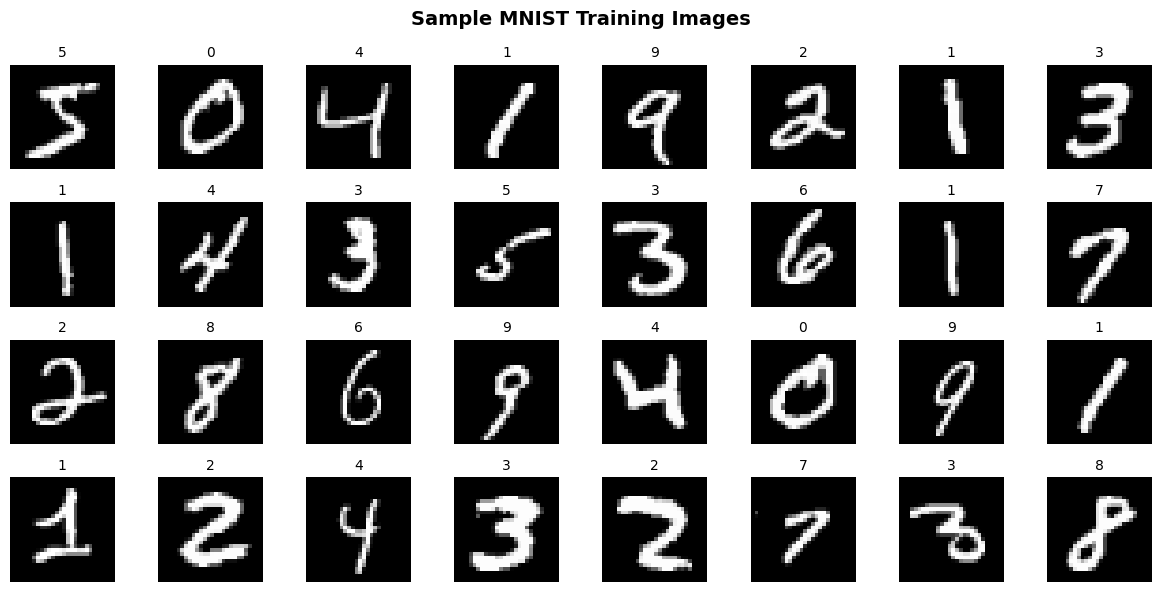

Saved: outputs/sample_mnist.png


In [3]:
# ── Visualize sample images ───────────────────────────────────────
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
fig.suptitle('Sample MNIST Training Images', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    # image shape: [1, 28, 28] — squeeze removes the channel dimension → [28, 28]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(str(label), fontsize=10)
    ax.axis('off')  # Hide axes ticks

plt.tight_layout()
plt.savefig('outputs/sample_mnist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/sample_mnist.png')

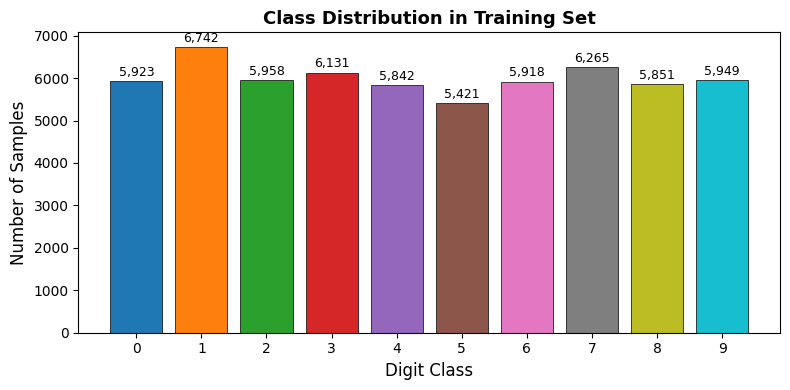

The dataset is well-balanced — each digit has ~6,000 training examples.


In [4]:
# ── Check class distribution ──────────────────────────────────────
# Is the dataset balanced? (Do all digits 0-9 appear equally often?)
labels = [train_dataset[i][1] for i in range(len(train_dataset))]
unique, counts = np.unique(labels, return_counts=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(unique, counts, color=plt.cm.tab10(unique / 9.0), edgecolor='black', linewidth=0.5)
ax.set_xlabel('Digit Class', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Class Distribution in Training Set', fontsize=13, fontweight='bold')
ax.set_xticks(unique)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('The dataset is well-balanced — each digit has ~6,000 training examples.')

---
## Section 4: Define the Neural Network

### The Architecture

Here's exactly what our network looks like:

```
┌─────────────────────────────────────────────────────────────────────┐
│                     FEEDFORWARD NEURAL NETWORK                      │
├──────────────┬───────────────────┬───────────────────┬──────────────┤
│  Input Layer │  Hidden Layer 1   │  Hidden Layer 2   │ Output Layer │
│              │                   │                   │              │
│  784 neurons │   256 neurons     │   128 neurons     │  10 neurons  │
│  (28×28 px   │   + ReLU          │   + ReLU          │  (one per    │
│   flattened) │   + Dropout(0.2)  │   + Dropout(0.2)  │   digit 0-9) │
└──────────────┴───────────────────┴───────────────────┴──────────────┘
```

### Key Concepts

**ReLU (Rectified Linear Unit)** — The activation function after each linear layer.  
Formula: `f(x) = max(0, x)` — it simply sets all negative values to zero.  
Why? Without activation functions, stacking linear layers is mathematically equivalent to just ONE linear layer — the network couldn't learn complex patterns. ReLU adds the "non-linearity" needed to learn.

**Dropout** — A regularization technique. During training, it randomly "turns off" 20% of neurons each forward pass.  
Why? It forces the network to not rely too heavily on any single neuron — making it more **robust and general**. It's disabled automatically during evaluation.

**`nn.Sequential`** — A convenient PyTorch container that chains layers in order. The output of one layer automatically becomes the input of the next.

**`nn.Module`** — The base class for all PyTorch models. By inheriting from it, our class gets a ton of built-in functionality (parameter tracking, GPU transfer, saving/loading, etc.).

In [5]:
class DigitClassifier(nn.Module):
    """
    Feedforward neural network for MNIST digit classification.

    Architecture:
        Input  : 784  (28×28 flattened grayscale image)
        Layer 1: 784 → 256  (Linear + ReLU + Dropout 20%)
        Layer 2: 256 → 128  (Linear + ReLU + Dropout 20%)
        Output : 128 → 10   (Linear, raw logits for each digit class)
    """

    def __init__(self):
        super(DigitClassifier, self).__init__()   # Always call parent __init__

        self.network = nn.Sequential(
            # ── Input → Hidden Layer 1 ───────────────────────────
            nn.Flatten(),                  # Reshape [B,1,28,28] → [B,784]
            nn.Linear(784, 256),           # Learnable weights: 784×256 + 256 biases
            nn.ReLU(),                     # Non-linearity: f(x) = max(0, x)
            nn.Dropout(p=0.2),             # Drop 20% of neurons randomly during training

            # ── Hidden Layer 1 → Hidden Layer 2 ─────────────────
            nn.Linear(256, 128),           # Learnable weights: 256×128 + 128 biases
            nn.ReLU(),
            nn.Dropout(p=0.2),

            # ── Hidden Layer 2 → Output ──────────────────────────
            nn.Linear(128, 10)             # 10 output scores (one per digit 0-9)
            # Note: No softmax here! CrossEntropyLoss includes it internally.
        )

    def forward(self, x):
        """
        Forward pass: define how data flows through the network.
        Called automatically when you do: output = model(input)
        """
        return self.network(x)


# ── Instantiate the model and move it to our device (CPU/GPU/MPS) ─
model = DigitClassifier().to(device)

# ── Print a summary of the architecture ──────────────────────────
print('Model Architecture:')
print('=' * 55)
print(model)
print('=' * 55)

# Count total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')
print('(These are all the weights and biases the network will learn)')

Model Architecture:
DigitClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total trainable parameters: 235,146
(These are all the weights and biases the network will learn)


---
## Section 5: Loss Function & Optimizer

### Loss Function: CrossEntropyLoss

The **loss function** measures how wrong the model's prediction is. During training, we want to minimize this number.

**CrossEntropyLoss** is the standard choice for multi-class classification (when there are more than 2 categories). It:
1. Applies softmax to convert raw scores (logits) into probabilities
2. Penalizes the model heavily when it's confidently wrong
3. Gives a loss of 0 for a perfect prediction

### Optimizer: Adam

The **optimizer** decides *how* to update the model's weights based on the loss.

**Adam** (Adaptive Moment Estimation) is the most popular optimizer in deep learning. It:
- Automatically adjusts the learning rate for each parameter
- Combines the best ideas from two other optimizers (Momentum + RMSProp)
- Converges fast and works well with minimal tuning

The `learning_rate=0.001` controls the size of each update step. Too large → overshoots. Too small → trains very slowly.

In [6]:
# ── Loss function ─────────────────────────────────────────────────
# CrossEntropyLoss = Softmax + Negative Log-Likelihood Loss
# It expects raw logits (not softmax outputs) as input.
criterion = nn.CrossEntropyLoss()

# ── Optimizer ─────────────────────────────────────────────────────
# model.parameters() gives Adam all the weights it needs to update.
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f'Loss function : {criterion.__class__.__name__}')
print(f'Optimizer     : {optimizer.__class__.__name__}')
print(f'Learning rate : {LEARNING_RATE}')

Loss function : CrossEntropyLoss
Optimizer     : Adam
Learning rate : 0.001


---
## Section 6: Training Loop

This is where the actual **learning** happens. Let's walk through what happens in each training step:

1. **Forward pass** — Feed a batch of images through the network → get predictions
2. **Compute loss** — Compare predictions to true labels using CrossEntropyLoss
3. **Backward pass** — PyTorch automatically computes gradients (via backpropagation)
4. **Update weights** — The optimizer adjusts all weights to reduce the loss
5. **Zero gradients** — Reset gradients to zero (they accumulate by default in PyTorch)

This loop runs for every batch in every epoch. One **epoch** = one full pass through all 60,000 training images.

After each epoch, we also run an **evaluation pass** on the test set to check how well the model generalizes to data it has never seen.

In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Train the model for exactly one epoch.
    Returns: average loss and accuracy over all batches.
    """
    model.train()   # Set model to TRAINING mode (enables Dropout)

    total_loss     = 0.0
    total_correct  = 0
    total_samples  = 0

    for images, labels in loader:
        # Move data to the same device as the model
        images, labels = images.to(device), labels.to(device)

        # ── Step 1: Zero the gradients from the previous batch ────
        optimizer.zero_grad()

        # ── Step 2: Forward pass ──────────────────────────────────
        outputs = model(images)                  # Shape: [batch_size, 10]

        # ── Step 3: Compute loss ──────────────────────────────────
        loss = criterion(outputs, labels)

        # ── Step 4: Backward pass (compute gradients) ─────────────
        loss.backward()

        # ── Step 5: Update weights ────────────────────────────────
        optimizer.step()

        # ── Track metrics ─────────────────────────────────────────
        total_loss += loss.item() * images.size(0)   # Accumulate weighted loss
        predicted   = outputs.argmax(dim=1)          # Take the class with highest score
        total_correct  += (predicted == labels).sum().item()
        total_samples  += images.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    """
    Evaluate the model on a dataset (no gradient computation).
    Returns: average loss and accuracy.
    """
    model.eval()   # Set model to EVALUATION mode (disables Dropout)

    total_loss    = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():   # Disable gradient tracking for efficiency
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs  = model(images)
            loss     = criterion(outputs, labels)

            total_loss    += loss.item() * images.size(0)
            predicted      = outputs.argmax(dim=1)
            total_correct += (predicted == labels).sum().item()
            total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return avg_loss, accuracy


print('Training and evaluation functions defined.')
print('Ready to train!')

Training and evaluation functions defined.
Ready to train!


In [8]:
# ── Main Training Loop ────────────────────────────────────────────
# We record loss and accuracy at each epoch for plotting later.

history = {
    'train_loss': [], 'train_acc': [],
    'test_loss' : [], 'test_acc' : []
}

best_test_acc = 0.0
start_time    = time.time()

print(f'Training for {NUM_EPOCHS} epochs on {device}...')
print('-' * 68)
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Test Loss":>9} | {"Test Acc":>8}')
print('-' * 68)

for epoch in range(1, NUM_EPOCHS + 1):

    # Train for one epoch
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # Evaluate on test set
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    # Record history
    history['train_loss'].append(train_loss)
    history['train_acc' ].append(train_acc)
    history['test_loss' ].append(test_loss)
    history['test_acc'  ].append(test_acc)

    # Save best model
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), 'best_model.pth')
        marker = ' ← best'
    else:
        marker = ''

    print(f'{epoch:>6} | {train_loss:>10.4f} | {train_acc*100:>8.2f}% | '
          f'{test_loss:>9.4f} | {test_acc*100:>7.2f}%{marker}')

total_time = time.time() - start_time
print('-' * 68)
print(f'\nTraining complete in {total_time:.1f} seconds.')
print(f'Best test accuracy: {best_test_acc*100:.2f}%')
print('Model saved to: best_model.pth')

Training for 10 epochs on mps...
--------------------------------------------------------------------
 Epoch | Train Loss | Train Acc | Test Loss | Test Acc
--------------------------------------------------------------------


     1 |     0.2818 |    91.31% |    0.1139 |   96.55% ← best


     2 |     0.1305 |    95.98% |    0.0957 |   97.08% ← best


     3 |     0.0995 |    97.02% |    0.0839 |   97.29% ← best


     4 |     0.0856 |    97.41% |    0.0776 |   97.63% ← best


...

     6 |     0.0656 |    97.89% |    0.0726 |   97.75%


     7 |     0.0569 |    98.21% |    0.0728 |   97.89% ← best


     8 |     0.0550 |    98.28% |    0.0728 |   97.86%


     9 |     0.0516 |    98.34% |    0.0713 |   98.09% ← best


    10 |     0.0470 |    98.40% |    0.0680 |   98.07%
--------------------------------------------------------------------

Training complete in 55.4 seconds.
Best test accuracy: 98.09%
Model saved to: best_model.pth


---
## Section 7: Visualize Training Curves

Training curves show us **how learning progressed** over the epochs.

**What to look for:**
- 📉 Loss should **decrease** — the model is getting better
- 📈 Accuracy should **increase** — the model is correct more often
- If training accuracy is much higher than test accuracy → **overfitting** (the model memorized training data but doesn't generalize)
- If both curves are close together → **healthy generalization** ✅

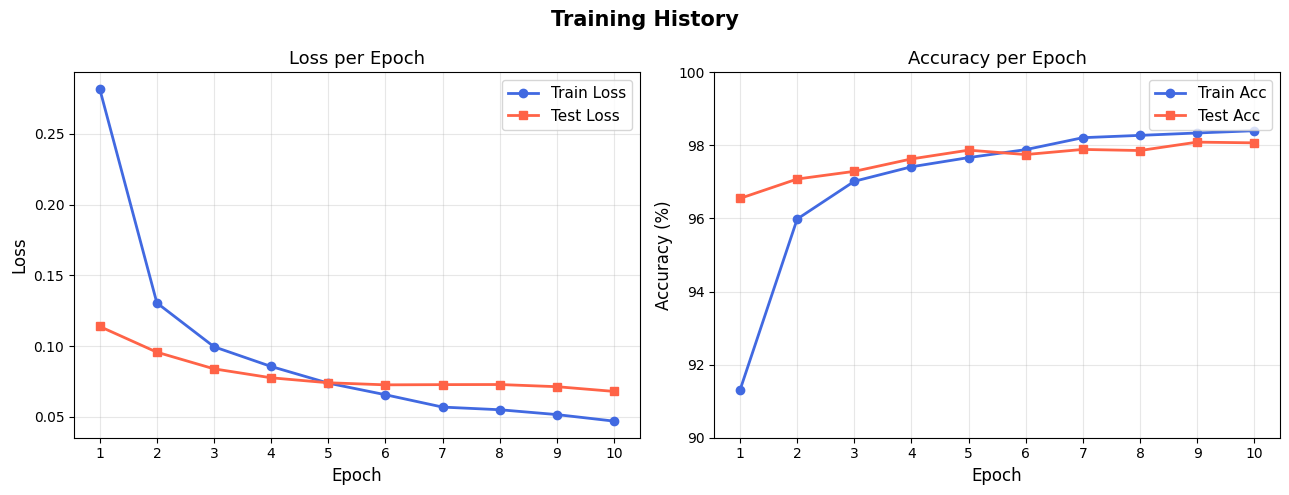

Saved: outputs/training_curves.png


In [9]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Training History', fontsize=15, fontweight='bold')

# ── Loss curves ───────────────────────────────────────────────────
ax1.plot(epochs_range, history['train_loss'], 'o-', color='royalblue',  label='Train Loss', linewidth=2)
ax1.plot(epochs_range, history['test_loss'],  's-', color='tomato',     label='Test Loss',  linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss',  fontsize=12)
ax1.set_title('Loss per Epoch', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(epochs_range)

# ── Accuracy curves ───────────────────────────────────────────────
ax2.plot(epochs_range, [a*100 for a in history['train_acc']], 'o-', color='royalblue', label='Train Acc', linewidth=2)
ax2.plot(epochs_range, [a*100 for a in history['test_acc']],  's-', color='tomato',    label='Test Acc',  linewidth=2)
ax2.set_xlabel('Epoch',    fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Accuracy per Epoch', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(epochs_range)
ax2.set_ylim(90, 100)

plt.tight_layout()
plt.savefig('outputs/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/training_curves.png')

---
## Section 8: Confusion Matrix

A **confusion matrix** is a 10×10 grid showing where the model makes mistakes.

- **Rows** = true digit labels
- **Columns** = predicted digit labels
- **Diagonal** = correct predictions (we want these to be dark/high)
- **Off-diagonal** = errors (e.g., the model predicted '9' when the true label was '4')

It's much more informative than a single accuracy number — it shows *which* digits get confused with each other.

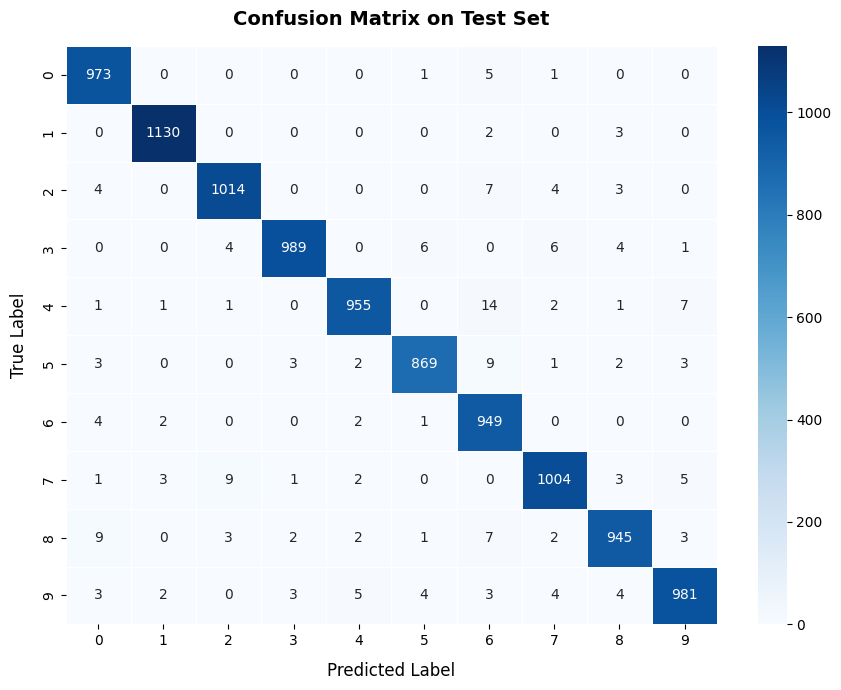

Saved: outputs/confusion_matrix.png

Per-class accuracy on test set:
------------------------------
  Digit 0: 973/980  (99.3%)
  Digit 1: 1130/1135  (99.6%)
  Digit 2: 1014/1032  (98.3%)
  Digit 3: 989/1010  (97.9%)
  Digit 4: 955/982  (97.3%)
  Digit 5: 869/892  (97.4%)
  Digit 6: 949/958  (99.1%)
  Digit 7: 1004/1028  (97.7%)
  Digit 8: 945/974  (97.0%)
  Digit 9: 981/1009  (97.2%)


In [10]:
# ── Load the best saved model ─────────────────────────────────────
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

# ── Collect all predictions and true labels ───────────────────────
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ── Build confusion matrix ────────────────────────────────────────
num_classes = 10
conf_matrix = np.zeros((num_classes, num_classes), dtype=int)
for true, pred in zip(all_labels, all_preds):
    conf_matrix[true][pred] += 1

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    conf_matrix,
    annot=True, fmt='d',           # Show integer counts in each cell
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10),
    linewidths=0.5,
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('True Label',      fontsize=12, labelpad=10)
ax.set_title('Confusion Matrix on Test Set', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/confusion_matrix.png')

# ── Per-class accuracy ────────────────────────────────────────────
print('\nPer-class accuracy on test set:')
print('-' * 30)
for digit in range(10):
    class_total   = conf_matrix[digit].sum()
    class_correct = conf_matrix[digit][digit]
    print(f'  Digit {digit}: {class_correct}/{class_total}  ({100*class_correct/class_total:.1f}%)')

---
## Section 9: Visualize Sample Predictions

Let's see the model in action — we'll display test images and compare what the model predicted vs. what the true label is.

- ✅ **Green title** = correct prediction
- ❌ **Red title** = wrong prediction

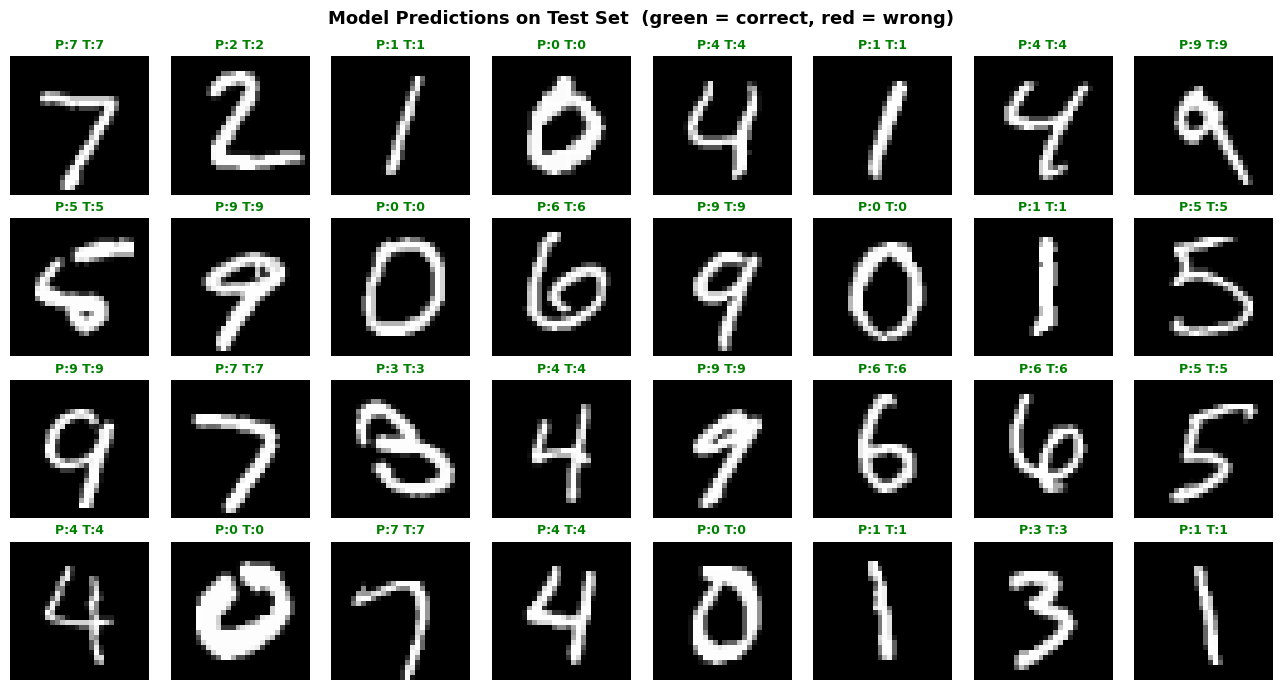

Saved: outputs/sample_predictions.png
  P = Predicted label
  T = True label


In [11]:
# ── Grab one batch of test images ─────────────────────────────────
test_iter = iter(test_loader)
images_batch, labels_batch = next(test_iter)

model.eval()
with torch.no_grad():
    outputs_batch = model(images_batch.to(device))
    preds_batch   = outputs_batch.argmax(dim=1).cpu()

# ── Plot ──────────────────────────────────────────────────────────
n_show = 32
fig, axes = plt.subplots(4, 8, figsize=(13, 7))
fig.suptitle('Model Predictions on Test Set  (green = correct, red = wrong)',
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i >= n_show:
        ax.axis('off')
        continue
    img   = images_batch[i].squeeze().numpy()
    true  = labels_batch[i].item()
    pred  = preds_batch[i].item()
    color = 'green' if pred == true else 'red'
    ax.imshow(img, cmap='gray')
    ax.set_title(f'P:{pred} T:{true}', color=color, fontsize=9, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('outputs/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/sample_predictions.png')
print('  P = Predicted label')
print('  T = True label')

---
## Section 10: Final Results Summary

In [12]:
# ── Final evaluation on the full test set ─────────────────────────
final_test_loss, final_test_acc = evaluate(model, test_loader, criterion, device)

print('=' * 50)
print('           FINAL RESULTS SUMMARY')
print('=' * 50)
print(f'  Dataset         : MNIST')
print(f'  Test samples    : 10,000')
print(f'  Architecture    : 784 → 256 → 128 → 10')
print(f'  Activation      : ReLU')
print(f'  Regularization  : Dropout (p=0.2)')
print(f'  Optimizer       : Adam (lr={LEARNING_RATE})')
print(f'  Loss function   : CrossEntropyLoss')
print(f'  Epochs trained  : {NUM_EPOCHS}')
print(f'  Batch size      : {BATCH_SIZE}')
print(f'  Total parameters: {total_params:,}')
print('-' * 50)
print(f'  Best test accuracy : {best_test_acc*100:.2f}%')
print(f'  Final test loss    : {final_test_loss:.4f}')
print('=' * 50)

# ── List all output files ─────────────────────────────────────────
print('\nGenerated output files:')
for f in sorted(os.listdir('outputs')):
    path = os.path.join('outputs', f)
    size = os.path.getsize(path) / 1024
    print(f'  outputs/{f}  ({size:.1f} KB)')

           FINAL RESULTS SUMMARY
  Dataset         : MNIST
  Test samples    : 10,000
  Architecture    : 784 → 256 → 128 → 10
  Activation      : ReLU
  Regularization  : Dropout (p=0.2)
  Optimizer       : Adam (lr=0.001)
  Loss function   : CrossEntropyLoss
  Epochs trained  : 10
  Batch size      : 64
  Total parameters: 235,146
--------------------------------------------------
  Best test accuracy : 98.09%
  Final test loss    : 0.0713

Generated output files:
  outputs/class_distribution.png  (40.1 KB)
  outputs/confusion_matrix.png  (66.3 KB)
  outputs/sample_mnist.png  (46.4 KB)
  outputs/sample_predictions.png  (58.5 KB)
  outputs/training_curves.png  (78.4 KB)
